# Home Credit - Structured Model Training (Fast, Stable, GPU-Ready)

This notebook is designed to be:

- **simple enough to run end-to-end**
- **faster than a heavy multi-model pipeline**
- **strong enough to stay competitive**
- **stable against common runtime issues**

## Main design choices

1. **CatBoost is used as the primary model**
   - handles categorical features directly
   - handles missing values naturally
   - supports GPU training
   - reduces preprocessing complexity

2. **Feature names are sanitized before modeling**
   - converts all names to strings
   - removes problematic characters
   - ensures unique column names
   - avoids common feature-name errors

3. **Training is done with fold-based validation**
   - out-of-fold (OOF) predictions
   - faster than very heavy stacking pipelines
   - more reliable than a single holdout split

4. **Optuna tuning is included but optional**
   - disabled by default for speed
   - can be enabled when needed

## 1. Optional installation
Uncomment the next cell only if these packages are not installed.

In [2]:
!pip install -U catboost optuna joblib

## 2. Imports and global settings

In [3]:

import warnings
warnings.filterwarnings("ignore")

import os
import gc
import re
import json
import shutil
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score

from catboost import CatBoostClassifier, Pool

try:
    import optuna
    OPTUNA_AVAILABLE = True
except Exception:
    OPTUNA_AVAILABLE = False

In [4]:

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

RANDOM_STATE = 42

# Speed / quality controls
FAST_MODE = True
RUN_TUNING = False

N_SPLITS = 3 if FAST_MODE else 5
N_TRIALS = 10 if FAST_MODE else 20

TARGET_COL = "TARGET"
ID_COL = "SK_ID_CURR"

## 3. Paths

In [5]:

REPORT_PATH = r"C:\Users\USER\DATA-SCINCE-AI\INCEPTION_BD_WORKSPACE\FSDS_BOOTCAMP\Machine_Learning_Projects\home-credit-default-risk\adfa\9.master_consolidated_report.csv"

TRAIN_PATH = r"C:\Users\USER\DATA-SCINCE-AI\INCEPTION_BD_WORKSPACE\FSDS_BOOTCAMP\Machine_Learning_Projects\home-credit-default-risk\Data\Processed_2\final_train_after_feature_engineering.csv"

TEST_PATH = r"C:\Users\USER\DATA-SCINCE-AI\INCEPTION_BD_WORKSPACE\FSDS_BOOTCAMP\Machine_Learning_Projects\home-credit-default-risk\Data\Processed_2\final_test_after_feature_engineering.csv"

OUTPUT_DIR = r"C:\Users\USER\DATA-SCINCE-AI\INCEPTION_BD_WORKSPACE\FSDS_BOOTCAMP\Machine_Learning_Projects\home-credit-default-risk\model_outputs_fast_gpu"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Output directory ready:")
print(OUTPUT_DIR)

Output directory ready:
C:\Users\USER\DATA-SCINCE-AI\INCEPTION_BD_WORKSPACE\FSDS_BOOTCAMP\Machine_Learning_Projects\home-credit-default-risk\model_outputs_fast_gpu


## 4. GPU detection

In [6]:

def has_nvidia_gpu():
    """Check whether an NVIDIA GPU is available."""
    if shutil.which("nvidia-smi") is None:
        return False
    try:
        result = subprocess.run(
            ["nvidia-smi", "-L"],
            capture_output=True,
            text=True,
            check=False
        )
        return result.returncode == 0 and "GPU" in result.stdout
    except Exception:
        return False

USE_GPU = has_nvidia_gpu()
print("GPU available:", USE_GPU)

GPU available: True


## 5. Helper functions

In [7]:

def clean_feature_names(columns):
    """
    Convert all feature names to safe strings and make them unique.
    """
    cleaned = []
    used = {}

    for i, col in enumerate(columns):
        original = str(col)

        new_col = original
        new_col = new_col.replace("[", "_")
        new_col = new_col.replace("]", "_")
        new_col = new_col.replace("<", "_lt_")
        new_col = new_col.replace(">", "_gt_")
        new_col = re.sub(r"[^0-9a-zA-Z_]+", "_", new_col)
        new_col = re.sub(r"_+", "_", new_col).strip("_")

        if new_col == "":
            new_col = f"feature_{i}"

        if new_col not in used:
            used[new_col] = 0
            final_name = new_col
        else:
            used[new_col] += 1
            final_name = f"{new_col}__dup_{used[new_col]}"

        cleaned.append(final_name)

    mapping_df = pd.DataFrame({
        "original_feature_name": [str(c) for c in columns],
        "clean_feature_name": cleaned
    })

    return cleaned, mapping_df

In [8]:

def replace_infinite_with_nan(df):
    df = df.copy()
    return df.replace([np.inf, -np.inf], np.nan)

In [9]:

def reduce_memory_usage(df):
    df = df.copy()

    float_cols = df.select_dtypes(include=["float64"]).columns
    int_cols = df.select_dtypes(include=["int64"]).columns

    for col in float_cols:
        df[col] = pd.to_numeric(df[col], downcast="float")

    for col in int_cols:
        df[col] = pd.to_numeric(df[col], downcast="integer")

    return df

In [10]:

def drop_duplicate_columns(df):
    return df.loc[:, ~df.columns.duplicated()].copy()

In [11]:

def prepare_categorical_columns(train_df, test_df, categorical_cols):
    train_df = train_df.copy()
    test_df = test_df.copy()

    for col in categorical_cols:
        train_df[col] = train_df[col].astype("string").fillna("__MISSING__")
        test_df[col] = test_df[col].astype("string").fillna("__MISSING__")

    return train_df, test_df

In [12]:

def safe_auc(y_true, y_pred):
    return roc_auc_score(y_true, y_pred)

In [13]:

def get_default_catboost_params(use_gpu=True, random_state=42, fast_mode=True):
    params = {
        "loss_function": "Logloss",
        "eval_metric": "AUC",
        "random_seed": random_state,
        "iterations": 2500 if fast_mode else 4500,
        "learning_rate": 0.03,
        "depth": 6,
        "l2_leaf_reg": 8.0,
        "min_data_in_leaf": 40,
        "bootstrap_type": "Bernoulli",
        "subsample": 0.80,
        "random_strength": 1.0,
        "od_type": "Iter",
        "od_wait": 150 if fast_mode else 250,
        "use_best_model": True,
        "allow_writing_files": False,
        "verbose": 200
    }

    if use_gpu:
        params["task_type"] = "GPU"
        params["devices"] = "0"
    else:
        params["task_type"] = "CPU"

    return params

In [14]:

def train_catboost_cv(
    X,
    y,
    X_test,
    cat_cols,
    params,
    n_splits=3,
    random_state=42
):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    oof_preds = np.zeros(len(X), dtype="float32")
    test_preds = np.zeros(len(X_test), dtype="float32")

    fold_scores = []
    feature_importances = []
    best_iterations = []
    models = []

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):
        print("=" * 80)
        print(f"Fold {fold}/{n_splits}")
        print("=" * 80)

        X_train_fold = X.iloc[train_idx].copy()
        y_train_fold = y.iloc[train_idx].copy()

        X_valid_fold = X.iloc[valid_idx].copy()
        y_valid_fold = y.iloc[valid_idx].copy()

        train_pool = Pool(
            data=X_train_fold,
            label=y_train_fold,
            cat_features=cat_cols
        )

        valid_pool = Pool(
            data=X_valid_fold,
            label=y_valid_fold,
            cat_features=cat_cols
        )

        test_pool = Pool(
            data=X_test,
            cat_features=cat_cols
        )

        model = CatBoostClassifier(**params)

        model.fit(
            train_pool,
            eval_set=valid_pool
        )

        valid_pred = model.predict_proba(valid_pool)[:, 1]
        test_pred = model.predict_proba(test_pool)[:, 1]

        oof_preds[valid_idx] = valid_pred
        test_preds += test_pred / n_splits

        fold_auc = safe_auc(y_valid_fold, valid_pred)
        fold_scores.append(fold_auc)

        best_iter = model.get_best_iteration()
        if best_iter is None or best_iter <= 0:
            best_iter = params["iterations"]
        best_iterations.append(int(best_iter))

        fold_importance = pd.DataFrame({
            "feature": X.columns,
            "importance": model.get_feature_importance(),
            "fold": fold
        })
        feature_importances.append(fold_importance)

        models.append(model)

        print(f"Fold {fold} ROC-AUC: {fold_auc:.6f}")
        print(f"Fold {fold} best iteration: {best_iter}")

        del X_train_fold, X_valid_fold, y_train_fold, y_valid_fold
        del train_pool, valid_pool, test_pool
        gc.collect()

    overall_auc = safe_auc(y, oof_preds)
    fi_df = pd.concat(feature_importances, axis=0).reset_index(drop=True)

    print("\nCV ROC-AUC scores:", np.round(fold_scores, 6))
    print("Mean CV ROC-AUC  :", np.mean(fold_scores))
    print("OOF ROC-AUC      :", overall_auc)
    print("Best iterations  :", best_iterations)

    return oof_preds, test_preds, fold_scores, fi_df, best_iterations, models

In [15]:

def train_final_catboost_model(X, y, X_test, cat_cols, base_params, best_iterations):
    final_iterations = int(np.median(best_iterations))
    final_iterations = max(final_iterations, 200)

    final_params = base_params.copy()
    final_params["iterations"] = final_iterations
    final_params["use_best_model"] = False
    final_params["verbose"] = 200

    train_pool = Pool(
        data=X,
        label=y,
        cat_features=cat_cols
    )

    test_pool = Pool(
        data=X_test,
        cat_features=cat_cols
    )

    final_model = CatBoostClassifier(**final_params)
    final_model.fit(train_pool)

    test_pred = final_model.predict_proba(test_pool)[:, 1]

    return final_model, test_pred, final_iterations

In [16]:

def plot_feature_importance(fi_df, top_n=25, title="Top Feature Importances"):
    fi_summary = (
        fi_df.groupby("feature", as_index=False)["importance"]
        .mean()
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    plt.figure(figsize=(12, 8))
    sns.barplot(
        data=fi_summary.head(top_n),
        x="importance",
        y="feature"
    )
    plt.title(title)
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()

    return fi_summary

## 6. Load datasets

In [17]:

report_df = None

if os.path.exists(REPORT_PATH):
    try:
        report_df = pd.read_csv(REPORT_PATH)
        print("Structural audit report loaded successfully.")
        print("Report shape:", report_df.shape)
    except Exception as e:
        print("Report could not be loaded:", e)
else:
    print("Report file not found. Training will continue without it.")

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

Structural audit report loaded successfully.
Report shape: (584, 196)
Train shape: (307511, 875)
Test shape : (48744, 874)


## 7. Basic validation

In [18]:

assert TARGET_COL in train_df.columns, f"{TARGET_COL} not found in train dataset."
assert TARGET_COL not in test_df.columns, f"{TARGET_COL} should not exist in test dataset."

print("Target found in train:", TARGET_COL in train_df.columns)
print("Target found in test :", TARGET_COL in test_df.columns)
print("ID found in train    :", ID_COL in train_df.columns)
print("ID found in test     :", ID_COL in test_df.columns)

print("\nTarget distribution:")
print(train_df[TARGET_COL].value_counts(dropna=False))
print("\nTarget percentage:")
print((train_df[TARGET_COL].value_counts(normalize=True, dropna=False) * 100).round(4))

Target found in train: True
Target found in test : False
ID found in train    : False
ID found in test     : False

Target distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Target percentage:
TARGET
0   91.927100
1    8.072900
Name: proportion, dtype: float64


In [19]:

if report_df is not None:
    display(report_df.head(5))

,Unnamed: 0,column,datatype_current_dtype_report,datatype_suggested_dtype_report,semantic_current_dtype_report,semantic_semantic_type_guess,key_id_like_flag,key_is_primary_key_like,key_is_foreign_key_like,pattern_current_dtype_report,pattern_boolean_like_string_detection,pattern_numeric_like_object_detection,pattern_date_like_object_detection,train_content_current_dtype_report,train_content_non_null_count,train_content_unique_count,train_content_unique_ratio,train_content_avg_string_length,train_content_text_vs_categorical_split,train_content_mixed_type_flag,clean_current_dtype_report,clean_special_character_flag,clean_whitespace_issue_flag,clean_format_inconsistency_flag,clean_leading_or_trailing_space_ratio,clean_multiple_space_ratio,clean_special_character_ratio,dtype,missing_count,missing_percentage,missing_group,imputation_strategy,recommendation,unique_values,non_missing_count,completeness,sample_values,dtype_r1,missing_count_r1,missing_percentage_r1,non_missing_count_r1,target_type,test_used,effect_size,p_value,signal_score,missing_indicator_recommended,missing_pattern_guess,positive_label,target_positive_rate_missing,target_positive_rate_non_missing,target_rate_gap_abs,odds_ratio,distribution_shift_jsd,direction,mutual_info,missing_count_r2,co_missing_columns_count,co_missing_columns,null_placeholder_found,detected_placeholders,overall_missingness_score,non_null_count_x,unique_count,unique_percentage,duplicate_count,duplicate_value_ratio,constant_flag,top_value_percentage,quasi_constant_flag,top_value,top_value_count,top_values_preview,non_null_count_y,dominant_value,dominant_value_pct,second_dominant_value,second_dominant_pct,top_values,suspicious_uniformity_flag,dominance_note,non_null_count,missing_count_x,missing_pct,cardinality_count,cardinality_group,high_cardinality_flag,very_high_cardinality_flag,potential_id_flag,numeric_categorical_flag,encoding_recommendation,missing_count_y,top_category,top_category_percentage,rare_category_count,rare_category_percentage,rare_grouping_recommended,category_distribution_balance,normalized_entropy,high_cardinality,unseen_category_risk,unseen_category_count,unseen_category_ratio,unseen_categories,potential_typos,train_category_count,test_category_count,train_top_categories,test_top_categories,count,min_value,max_value,range_value,mean_value,median_value,std_dev,coef_of_variation,p25,p75,iqr_x,skewness_x,kurtosis_x,zero_count,negative_count,q1_x,q3_x,iqr_y,lower_bound,upper_bound,outlier_count_x,outlier_percentage,missing_rate,mean,median,std,min,q1_y,q3_y,max,iqr,skewness_y,kurtosis_y,outlier_count_y,outlier_rate,skew_label,variance_flag,normality_pvalue,normality_label,iqr_q1,iqr_q3,iqr_value,iqr_lower_bound,iqr_upper_bound,iqr_lower_count,iqr_upper_count,iqr_total_count,iqr_total_pct,extreme_iqr_count,extreme_iqr_pct,zscore_lower_bound,zscore_upper_bound,zscore_lower_count,zscore_upper_count,zscore_total_count,zscore_total_pct,mod_zscore_mad,mod_zscore_count,mod_zscore_pct,pctl_lower_bound,pctl_upper_bound,pctl_count,pctl_pct,kurtosis,distribution_type_x,is_heavy_tailed,is_skewed,heavy_tail_flag,has_outliers,outlier_severity,suggested_treatment,winsorize_lower,winsorize_upper,distribution_type_y,transformation_recommendation,scaling_needed,clipping_recommendation,winsorization_recommendation,is_numeric,is_discrete,is_near_constant,zero_inflation_flag,binning_opportunity,structure_score,recommended_action,reason,zero_ratio
0,0,AMT_ANNUITY,float64,float64,float64,numeric_continuous,False,False,False,float64,False,False,False,float64,307499,13672,0.044462,NaN,not_applicable,False,float64,False,False,False,NaN,NaN,NaN,float64,12,0.000000,low_missing,mean/median,Mean (if normal) or Median (if skewed),13672,307499,100.000000,"['24700.5', '35698.5', '6750.0']",float64,12.000000,0.000000,"307,499.000000",binary_classification,fisher_exact,0.001851,0.616206,0.203939,False,likely_random_or_weak_signal,1.000000,0.000000,0.080732,0.080732,0.000000,0.203939,lower_positive_rate_when_missin

## 8. Prepare features and target

In [20]:

if ID_COL in train_df.columns:
    train_ids = train_df[ID_COL].copy()
else:
    train_ids = pd.Series(np.arange(len(train_df)), name=ID_COL)

if ID_COL in test_df.columns:
    test_ids = test_df[ID_COL].copy()
else:
    test_ids = pd.Series(np.arange(len(test_df)), name=ID_COL)

y = train_df[TARGET_COL].copy()

unique_target_values = sorted(pd.Series(y).dropna().unique().tolist())
assert set(unique_target_values).issubset({0, 1}), f"Target must be binary 0/1. Found: {unique_target_values}"
y = y.astype("int8")

drop_train_cols = [col for col in [TARGET_COL, ID_COL] if col in train_df.columns]
drop_test_cols = [col for col in [ID_COL] if col in test_df.columns]

X = train_df.drop(columns=drop_train_cols).copy()
X_test = test_df.drop(columns=drop_test_cols).copy()

X = drop_duplicate_columns(X)
X_test = drop_duplicate_columns(X_test)

common_cols = [col for col in X.columns if col in X_test.columns]
X = X[common_cols].copy()
X_test = X_test[common_cols].copy()

print("Training feature shape:", X.shape)
print("Test feature shape    :", X_test.shape)
print("Common feature count  :", len(common_cols))

Training feature shape: (307511, 874)
Test feature shape    : (48744, 874)
Common feature count  : 874


## 9. Sanitize feature names and values

In [21]:

cleaned_cols, feature_name_mapping_df = clean_feature_names(X.columns)

X.columns = cleaned_cols
X_test.columns = cleaned_cols

feature_name_mapping_path = os.path.join(OUTPUT_DIR, "feature_name_mapping.csv")
feature_name_mapping_df.to_csv(feature_name_mapping_path, index=False)

print("Feature names sanitized and mapping saved.")
print(feature_name_mapping_path)

display(feature_name_mapping_df.head(10))

Feature names sanitized and mapping saved.
C:\Users\USER\DATA-SCINCE-AI\INCEPTION_BD_WORKSPACE\FSDS_BOOTCAMP\Machine_Learning_Projects\home-credit-default-risk\model_outputs_fast_gpu\feature_name_mapping.csv


,original_feature_name,clean_feature_name
0,CNT_CHILDREN,CNT_CHILDREN
1,AMT_INCOME_TOTAL,AMT_INCOME_TOTAL
2,AMT_CREDIT,AMT_CREDIT
3,AMT_ANNUITY,AMT_ANNUITY
4,AMT_GOODS_PRICE,AMT_GOODS_PRICE
5,REGION_POPULATION_RELATIVE,REGION_POPULATION_RELATIVE
6,DAYS_BIRTH,DAYS_BIRTH
7,DAYS_EMPLOYED,DAYS_EMPLOYED
8,DAYS_REGISTRATION,DAYS_REGISTRATION
9,DAYS_ID_PUBLISH,DAYS_ID_PUBLISH


In [22]:

X = replace_infinite_with_nan(X)
X_test = replace_infinite_with_nan(X_test)

X = reduce_memory_usage(X)
X_test = reduce_memory_usage(X_test)

print("Value sanitization and memory reduction complete.")

Value sanitization and memory reduction complete.


## 10. Identify categorical and numeric columns

In [23]:

categorical_cols = X.select_dtypes(include=["object", "category", "bool", "string"]).columns.tolist()
numeric_cols = [col for col in X.columns if col not in categorical_cols]

print("Categorical columns:", len(categorical_cols))
print("Numeric columns    :", len(numeric_cols))
print("\nSample categorical columns:")
print(categorical_cols[:20])

Categorical columns: 131
Numeric columns    : 743

Sample categorical columns:
['OCCUPATION_TYPE', 'NAME_CONTRACT_TYPE_Cash_loans', 'NAME_CONTRACT_TYPE_Revolving_loans', 'CODE_GENDER_F', 'CODE_GENDER_M', 'CODE_GENDER_XNA', 'FLAG_OWN_CAR_N', 'FLAG_OWN_CAR_Y', 'FLAG_OWN_REALTY_N', 'FLAG_OWN_REALTY_Y', 'NAME_TYPE_SUITE_Children', 'NAME_TYPE_SUITE_Family', 'NAME_TYPE_SUITE_Group_of_people', 'NAME_TYPE_SUITE_Other_A', 'NAME_TYPE_SUITE_Other_B', 'NAME_TYPE_SUITE_Spouse_partner', 'NAME_TYPE_SUITE_Unaccompanied', 'NAME_TYPE_SUITE_Unknown', 'NAME_INCOME_TYPE_Businessman', 'NAME_INCOME_TYPE_Commercial_associate']


In [24]:

X, X_test = prepare_categorical_columns(X, X_test, categorical_cols)

print("Categorical column preparation complete.")

Categorical column preparation complete.


## 11. Quick report-based reference (optional)

In [25]:

if report_df is not None:
    print("Structural report is available for reference.")
    print("Report columns:")
    print(report_df.columns.tolist()[:30])
else:
    print("No structural report loaded.")

Structural report is available for reference.
Report columns:
['Unnamed: 0', 'column', 'datatype_current_dtype_report', 'datatype_suggested_dtype_report', 'semantic_current_dtype_report', 'semantic_semantic_type_guess', 'key_id_like_flag', 'key_is_primary_key_like', 'key_is_foreign_key_like', 'pattern_current_dtype_report', 'pattern_boolean_like_string_detection', 'pattern_numeric_like_object_detection', 'pattern_date_like_object_detection', 'train_content_current_dtype_report', 'train_content_non_null_count', 'train_content_unique_count', 'train_content_unique_ratio', 'train_content_avg_string_length', 'train_content_text_vs_categorical_split', 'train_content_mixed_type_flag', 'clean_current_dtype_report', 'clean_special_character_flag', 'clean_whitespace_issue_flag', 'clean_format_inconsistency_flag', 'clean_leading_or_trailing_space_ratio', 'clean_multiple_space_ratio', 'clean_special_character_ratio', 'dtype', 'missing_count', 'missing_percentage']


## 12. Fast single-split baseline

In [26]:

X_train_base, X_valid_base, y_train_base, y_valid_base = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

baseline_params = get_default_catboost_params(
    use_gpu=USE_GPU,
    random_state=RANDOM_STATE,
    fast_mode=FAST_MODE
)

baseline_train_pool = Pool(
    data=X_train_base,
    label=y_train_base,
    cat_features=categorical_cols
)

baseline_valid_pool = Pool(
    data=X_valid_base,
    label=y_valid_base,
    cat_features=categorical_cols
)

baseline_model = CatBoostClassifier(**baseline_params)
baseline_model.fit(
    baseline_train_pool,
    eval_set=baseline_valid_pool
)

baseline_valid_pred = baseline_model.predict_proba(baseline_valid_pool)[:, 1]
baseline_auc = safe_auc(y_valid_base, baseline_valid_pred)

print("Baseline validation ROC-AUC:", round(baseline_auc, 6))

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7100573	best: 0.7100573 (0)	total: 7.49s	remaining: 5h 11m 45s
200:	test: 0.7779248	best: 0.7779248 (200)	total: 12.2s	remaining: 2m 19s
400:	test: 0.7842745	best: 0.7842745 (400)	total: 16.3s	remaining: 1m 25s
600:	test: 0.7869488	best: 0.7869574 (599)	total: 20.4s	remaining: 1m 4s
800:	test: 0.7880315	best: 0.7880365 (797)	total: 24.3s	remaining: 51.6s
1000:	test: 0.7887666	best: 0.7887666 (1000)	total: 28.8s	remaining: 43.1s
1200:	test: 0.7893538	best: 0.7893722 (1179)	total: 33s	remaining: 35.7s
1400:	test: 0.7897221	best: 0.7897361 (1396)	total: 37.1s	remaining: 29.1s
1600:	test: 0.7900574	best: 0.7900620 (1595)	total: 41.3s	remaining: 23.2s
1800:	test: 0.7902675	best: 0.7902964 (1763)	total: 45.5s	remaining: 17.7s
2000:	test: 0.7906056	best: 0.7906056 (2000)	total: 50.2s	remaining: 12.5s
2200:	test: 0.7909358	best: 0.7909358 (2200)	total: 54.3s	remaining: 7.37s
2400:	test: 0.7910631	best: 0.7910631 (2400)	total: 58.6s	remaining: 2.42s
2499:	test: 0.7912936	best: 0.7913

## 13. Cross-validated training

In [27]:

cv_params = get_default_catboost_params(
    use_gpu=USE_GPU,
    random_state=RANDOM_STATE,
    fast_mode=FAST_MODE
)

oof_preds, test_preds_cv, fold_scores, fi_df, best_iterations, cv_models = train_catboost_cv(
    X=X,
    y=y,
    X_test=X_test,
    cat_cols=categorical_cols,
    params=cv_params,
    n_splits=N_SPLITS,
    random_state=RANDOM_STATE
)

Fold 1/3


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7136905	best: 0.7136905 (0)	total: 18ms	remaining: 45s
200:	test: 0.7762811	best: 0.7762811 (200)	total: 3.93s	remaining: 45s
400:	test: 0.7825483	best: 0.7825483 (400)	total: 7.83s	remaining: 41s
600:	test: 0.7848903	best: 0.7848909 (598)	total: 11.6s	remaining: 36.5s
800:	test: 0.7861508	best: 0.7861508 (800)	total: 15.2s	remaining: 32.3s
1000:	test: 0.7872375	best: 0.7872375 (1000)	total: 18.8s	remaining: 28.2s
1200:	test: 0.7879573	best: 0.7879692 (1198)	total: 22.6s	remaining: 24.5s
1400:	test: 0.7883430	best: 0.7883708 (1356)	total: 26.9s	remaining: 21.1s
1600:	test: 0.7886732	best: 0.7886779 (1597)	total: 30.8s	remaining: 17.3s
1800:	test: 0.7888732	best: 0.7888732 (1800)	total: 34.9s	remaining: 13.6s
2000:	test: 0.7890452	best: 0.7890778 (1983)	total: 39s	remaining: 9.72s
2200:	test: 0.7892287	best: 0.7892287 (2200)	total: 43.3s	remaining: 5.89s
2400:	test: 0.7894042	best: 0.7894042 (2400)	total: 47.7s	remaining: 1.97s
2499:	test: 0.7894869	best: 0.7894948 (2472)	tot

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7128887	best: 0.7128887 (0)	total: 30.3ms	remaining: 1m 15s
200:	test: 0.7761071	best: 0.7761071 (200)	total: 4.28s	remaining: 49s
400:	test: 0.7827912	best: 0.7827912 (400)	total: 8.41s	remaining: 44s
600:	test: 0.7849040	best: 0.7849074 (592)	total: 13.1s	remaining: 41.5s
800:	test: 0.7861387	best: 0.7861387 (800)	total: 17.5s	remaining: 37.2s
1000:	test: 0.7870217	best: 0.7870217 (1000)	total: 21.8s	remaining: 32.7s
1200:	test: 0.7877228	best: 0.7877228 (1200)	total: 26s	remaining: 28.2s
1400:	test: 0.7884046	best: 0.7884065 (1393)	total: 30.1s	remaining: 23.6s
1600:	test: 0.7886583	best: 0.7886692 (1592)	total: 34.4s	remaining: 19.3s
1800:	test: 0.7888398	best: 0.7888466 (1791)	total: 38.5s	remaining: 14.9s
2000:	test: 0.7891786	best: 0.7891850 (1992)	total: 42.5s	remaining: 10.6s
2200:	test: 0.7892055	best: 0.7892210 (2139)	total: 46.5s	remaining: 6.32s
2400:	test: 0.7893339	best: 0.7894044 (2363)	total: 50.5s	remaining: 2.08s
2499:	test: 0.7894017	best: 0.7894233 (2470

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7058333	best: 0.7058333 (0)	total: 19.7ms	remaining: 49.2s
200:	test: 0.7725349	best: 0.7725349 (200)	total: 4.22s	remaining: 48.2s
400:	test: 0.7794511	best: 0.7794511 (400)	total: 8.3s	remaining: 43.5s
600:	test: 0.7827657	best: 0.7827657 (600)	total: 12.4s	remaining: 39.3s
800:	test: 0.7847113	best: 0.7847113 (800)	total: 16.9s	remaining: 35.8s
1000:	test: 0.7857790	best: 0.7857825 (997)	total: 21.1s	remaining: 31.6s
1200:	test: 0.7867629	best: 0.7867629 (1200)	total: 25.4s	remaining: 27.5s
1400:	test: 0.7872974	best: 0.7873019 (1399)	total: 29.5s	remaining: 23.1s
1600:	test: 0.7878422	best: 0.7878422 (1600)	total: 33.8s	remaining: 19s
1800:	test: 0.7883294	best: 0.7883303 (1797)	total: 38.3s	remaining: 14.9s
2000:	test: 0.7886755	best: 0.7886755 (2000)	total: 42.1s	remaining: 10.5s
2200:	test: 0.7890109	best: 0.7890109 (2200)	total: 46.1s	remaining: 6.26s
2400:	test: 0.7892403	best: 0.7892418 (2380)	total: 49.8s	remaining: 2.05s
2499:	test: 0.7894336	best: 0.7894384 (249

In [28]:

cv_results_df = pd.DataFrame({
    "fold": list(range(1, len(fold_scores) + 1)),
    "roc_auc": fold_scores,
    "best_iteration": best_iterations
})

display(cv_results_df)

print("Mean CV ROC-AUC:", round(np.mean(fold_scores), 6))
print("OOF ROC-AUC    :", round(safe_auc(y, oof_preds), 6))

,fold,roc_auc,best_iteration
0,1,0.789495,2472
1,2,0.789423,2470
2,3,0.789438,2490


Mean CV ROC-AUC: 0.789452
OOF ROC-AUC    : 0.789445


## 14. Optional tuning with Optuna

In [31]:
if RUN_TUNING and not OPTUNA_AVAILABLE:
    print("Optuna is not installed. Install it first to run tuning.")
else:
    print("Installed")

Installed


In [38]:

if RUN_TUNING and OPTUNA_AVAILABLE:

    def objective(trial):
        params = {
            "loss_function": "Logloss",
            "eval_metric": "AUC",
            "random_seed": RANDOM_STATE,
            "iterations": 1800 if FAST_MODE else 3000,
            "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.08, log=True),
            "depth": trial.suggest_int("depth", 5, 8),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 2.0, 15.0),
            "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 20, 100),
            "bootstrap_type": "Bernoulli",
            "subsample": trial.suggest_float("subsample", 0.70, 0.95),
            "random_strength": trial.suggest_float("random_strength", 0.1, 2.0),
            "od_type": "Iter",
            "od_wait": 100,
            "use_best_model": True,
            "allow_writing_files": False,
            "verbose": False
        }

        if USE_GPU:
            params["task_type"] = "GPU"
            params["devices"] = "0"
        else:
            params["task_type"] = "CPU"

        inner_skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
        scores = []

        for tr_idx, va_idx in inner_skf.split(X, y):
            X_tr = X.iloc[tr_idx].copy()
            y_tr = y.iloc[tr_idx].copy()

            X_va = X.iloc[va_idx].copy()
            y_va = y.iloc[va_idx].copy()

            train_pool = Pool(X_tr, y_tr, cat_features=categorical_cols)
            valid_pool = Pool(X_va, y_va, cat_features=categorical_cols)

            model = CatBoostClassifier(**params)
            model.fit(train_pool, eval_set=valid_pool)

            pred = model.predict_proba(valid_pool)[:, 1]
            scores.append(safe_auc(y_va, pred))

            del X_tr, X_va, y_tr, y_va, train_pool, valid_pool, model
            gc.collect()

        return float(np.mean(scores))

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    print("Best Optuna score:", study.best_value)
    print("Best Optuna params:")
    print(study.best_params)

In [33]:

if RUN_TUNING and OPTUNA_AVAILABLE:
    tuned_params = get_default_catboost_params(
        use_gpu=USE_GPU,
        random_state=RANDOM_STATE,
        fast_mode=FAST_MODE
    )

    tuned_params.update(study.best_params)

    oof_preds_tuned, test_preds_tuned, fold_scores_tuned, fi_df_tuned, best_iterations_tuned, cv_models_tuned = train_catboost_cv(
        X=X,
        y=y,
        X_test=X_test,
        cat_cols=categorical_cols,
        params=tuned_params,
        n_splits=N_SPLITS,
        random_state=RANDOM_STATE
    )

    tuned_oof_auc = safe_auc(y, oof_preds_tuned)
    default_oof_auc = safe_auc(y, oof_preds)

    print("\nDefault OOF AUC:", round(default_oof_auc, 6))
    print("Tuned OOF AUC  :", round(tuned_oof_auc, 6))

    if tuned_oof_auc >= default_oof_auc:
        print("Using tuned model outputs.")
        final_cv_params = tuned_params
        final_oof_preds = oof_preds_tuned
        final_test_preds_cv = test_preds_tuned
        final_fold_scores = fold_scores_tuned
        final_fi_df = fi_df_tuned
        final_best_iterations = best_iterations_tuned
    else:
        print("Using default CV model outputs.")
        final_cv_params = cv_params
        final_oof_preds = oof_preds
        final_test_preds_cv = test_preds_cv
        final_fold_scores = fold_scores
        final_fi_df = fi_df
        final_best_iterations = best_iterations

else:
    final_cv_params = cv_params
    final_oof_preds = oof_preds
    final_test_preds_cv = test_preds_cv
    final_fold_scores = fold_scores
    final_fi_df = fi_df
    final_best_iterations = best_iterations

## 15. Final full-data training

In [34]:

final_model, final_test_preds, final_iterations = train_final_catboost_model(
    X=X,
    y=y,
    X_test=X_test,
    cat_cols=categorical_cols,
    base_params=final_cv_params,
    best_iterations=final_best_iterations
)

print("Final full-data model trained.")
print("Final iterations used:", final_iterations)

Default metric period is 5 because AUC is/are not implemented for GPU


0:	total: 21ms	remaining: 51.8s
200:	total: 4.92s	remaining: 55.6s
400:	total: 9.41s	remaining: 48.6s
600:	total: 13.9s	remaining: 43.2s
800:	total: 18s	remaining: 37.6s
1000:	total: 22.7s	remaining: 33.3s
1200:	total: 26.9s	remaining: 28.4s
1400:	total: 30.9s	remaining: 23.6s
1600:	total: 35.1s	remaining: 19.1s
1800:	total: 38.9s	remaining: 14.5s
2000:	total: 43.4s	remaining: 10.2s
2200:	total: 47.6s	remaining: 5.86s
2400:	total: 51.7s	remaining: 1.53s
2471:	total: 53.2s	remaining: 0us
Final full-data model trained.
Final iterations used: 2472


## 16. Feature importance

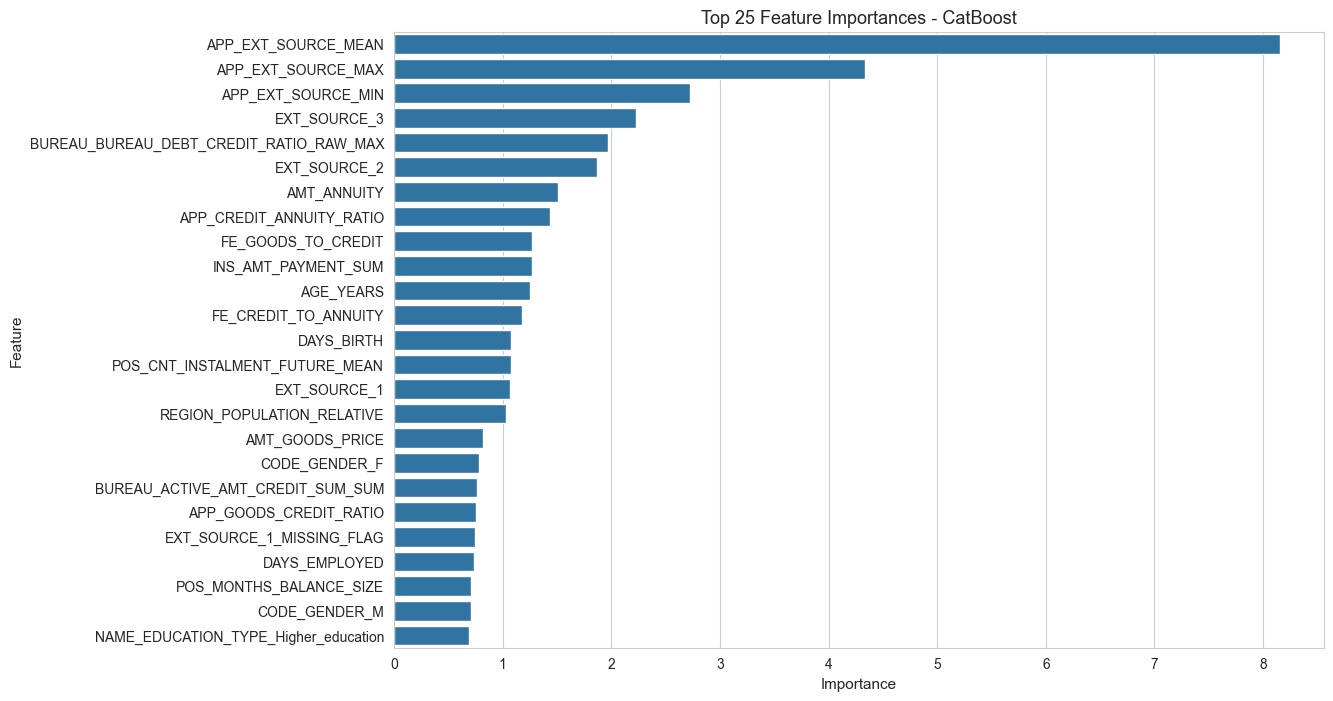

,feature,importance
0,APP_EXT_SOURCE_MEAN,8.151793
1,APP_EXT_SOURCE_MAX,4.336857
2,APP_EXT_SOURCE_MIN,2.721911
3,EXT_SOURCE_3,2.231144
4,BUREAU_BUREAU_DEBT_CREDIT_RATIO_RAW_MAX,1.968023
5,EXT_SOURCE_2,1.870687
6,AMT_ANNUITY,1.513828
7,APP_CREDIT_ANNUITY_RATIO,1.432954
8,FE_GOODS_TO_CREDIT,1.272321
9,INS_AMT_PAYMENT_SUM,1.270283


In [35]:

fi_summary = plot_feature_importance(
    final_fi_df,
    top_n=25,
    title="Top 25 Feature Importances - CatBoost"
)

display(fi_summary.head(25))

## 17. Save outputs

In [36]:

oof_df = pd.DataFrame({
    ID_COL: train_ids,
    TARGET_COL: y,
    "oof_prediction": final_oof_preds
})

oof_path = os.path.join(OUTPUT_DIR, "oof_predictions.csv")
oof_df.to_csv(oof_path, index=False)

submission_df = pd.DataFrame({
    ID_COL: test_ids,
    TARGET_COL: final_test_preds
})

submission_path = os.path.join(OUTPUT_DIR, "submission_catboost_fast_gpu.csv")
submission_df.to_csv(submission_path, index=False)

fi_path = os.path.join(OUTPUT_DIR, "feature_importance_catboost.csv")
fi_summary.to_csv(fi_path, index=False)

model_path = os.path.join(OUTPUT_DIR, "final_catboost_model.cbm")
final_model.save_model(model_path)

training_summary = {
    "gpu_used": USE_GPU,
    "fast_mode": FAST_MODE,
    "run_tuning": RUN_TUNING,
    "n_splits": N_SPLITS,
    "n_trials": N_TRIALS if RUN_TUNING else 0,
    "baseline_validation_auc": float(baseline_auc),
    "cv_scores": [float(x) for x in final_fold_scores],
    "mean_cv_auc": float(np.mean(final_fold_scores)),
    "oof_auc": float(safe_auc(y, final_oof_preds)),
    "final_iterations": int(final_iterations),
    "categorical_feature_count": int(len(categorical_cols)),
    "numeric_feature_count": int(len(numeric_cols)),
    "feature_count_used": int(X.shape[1])
}

summary_path = os.path.join(OUTPUT_DIR, "training_summary.json")
with open(summary_path, "w") as f:
    json.dump(training_summary, f, indent=4)

print("Saved files:")
print("OOF predictions :", oof_path)
print("Submission      :", submission_path)
print("Feature import. :", fi_path)
print("Model           :", model_path)
print("Summary         :", summary_path)
print("Feature mapping :", feature_name_mapping_path)

Saved files:
OOF predictions : C:\Users\USER\DATA-SCINCE-AI\INCEPTION_BD_WORKSPACE\FSDS_BOOTCAMP\Machine_Learning_Projects\home-credit-default-risk\model_outputs_fast_gpu\oof_predictions.csv
Submission      : C:\Users\USER\DATA-SCINCE-AI\INCEPTION_BD_WORKSPACE\FSDS_BOOTCAMP\Machine_Learning_Projects\home-credit-default-risk\model_outputs_fast_gpu\submission_catboost_fast_gpu.csv
Feature import. : C:\Users\USER\DATA-SCINCE-AI\INCEPTION_BD_WORKSPACE\FSDS_BOOTCAMP\Machine_Learning_Projects\home-credit-default-risk\model_outputs_fast_gpu\feature_importance_catboost.csv
Model           : C:\Users\USER\DATA-SCINCE-AI\INCEPTION_BD_WORKSPACE\FSDS_BOOTCAMP\Machine_Learning_Projects\home-credit-default-risk\model_outputs_fast_gpu\final_catboost_model.cbm
Summary         : C:\Users\USER\DATA-SCINCE-AI\INCEPTION_BD_WORKSPACE\FSDS_BOOTCAMP\Machine_Learning_Projects\home-credit-default-risk\model_outputs_fast_gpu\training_summary.json
Feature mapping : C:\Users\USER\DATA-SCINCE-AI\INCEPTION_BD_WORKS

## 18. Final summary

In [37]:

print("=" * 80)
print("MODEL TRAINING SUMMARY")
print("=" * 80)
print(f"GPU used                    : {USE_GPU}")
print(f"FAST_MODE                   : {FAST_MODE}")
print(f"RUN_TUNING                  : {RUN_TUNING}")
print(f"Number of folds             : {N_SPLITS}")
print(f"Training features used      : {X.shape[1]}")
print(f"Categorical feature count   : {len(categorical_cols)}")
print(f"Numeric feature count       : {len(numeric_cols)}")
print(f"Baseline validation ROC-AUC : {baseline_auc:.6f}")
print(f"Mean CV ROC-AUC             : {np.mean(final_fold_scores):.6f}")
print(f"OOF ROC-AUC                 : {safe_auc(y, final_oof_preds):.6f}")
print(f"Final full-data iterations  : {final_iterations}")
print("=" * 80)
print("Artifacts saved inside:")
print(OUTPUT_DIR)

MODEL TRAINING SUMMARY
GPU used                    : True
FAST_MODE                   : True
RUN_TUNING                  : False
Number of folds             : 3
Training features used      : 874
Categorical feature count   : 131
Numeric feature count       : 743
Baseline validation ROC-AUC : 0.791309
Mean CV ROC-AUC             : 0.789452
OOF ROC-AUC                 : 0.789445
Final full-data iterations  : 2472
Artifacts saved inside:
C:\Users\USER\DATA-SCINCE-AI\INCEPTION_BD_WORKSPACE\FSDS_BOOTCAMP\Machine_Learning_Projects\home-credit-default-risk\model_outputs_fast_gpu


## 19. Why this notebook is more stable than the previous version

This notebook reduces complexity and common errors by:

1. using **CatBoost as the main model**
2. avoiding unnecessary encoding-heavy pipelines
3. cleaning feature names before modeling
4. handling categorical columns consistently
5. replacing infinity values safely
6. using fold-based validation instead of only one split
7. making tuning optional for speed
8. using GPU automatically when available

## 20. Common issues already handled here

- `feature_names must be string, and may not contain [, ] or <`
- duplicate feature names after transformation
- train/test column mismatch
- mixed-type categorical columns
- `inf` and `-inf` values
- GPU not available -> automatic CPU fallback
- too-slow tuning -> optional tuning only

## 21. Recommended way to run

1. First run with:
   - `FAST_MODE = True`
   - `RUN_TUNING = False`

2. If the score is good and stable:
   - keep `FAST_MODE = True`
   - set `RUN_TUNING = True`

3. If you want a slower but stronger run:
   - `FAST_MODE = False`
   - `RUN_TUNING = True`